Install Dependencies (Run First)

In [36]:
!pip install gymnasium[atari] ale-py autorom torch torchvision
!AutoROM --accept-license


AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


Imports & Device Setup

In [37]:
import gymnasium as gym
import ale_py
import torch
import numpy as np

from gymnasium.wrappers import AtariPreprocessing
from gymnasium.wrappers import FrameStackObservation

gym.register_envs(ale_py)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("Gymnasium version:", gym.__version__)
print("Torch version:", torch.__version__)


Using device: cuda
Gymnasium version: 1.2.3
Torch version: 2.9.0+cu128


— Create Atari Environment Properly (For Gymnasium 1.2.3)

In [38]:
def make_env():
    env = gym.make("ALE/Breakout-v5", frameskip=1)

    env = AtariPreprocessing(
        env,
        grayscale_obs=True,
        scale_obs=False,
        frame_skip=4
    )

    env = FrameStackObservation(env, 4)

    return env

env = make_env()

state, info = env.reset()

print("State shape:", state.shape)
print("State dtype:", state.dtype)
print("Action space:", env.action_space.n)


State shape: (4, 84, 84)
State dtype: uint8
Action space: 4


Representation Network (h)

In [39]:
import torch.nn as nn

class RepresentationNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.float() / 255.0
        return self.conv(x)

representation_net = RepresentationNetwork().to(device)


test Representation network

In [40]:
state_tensor = torch.tensor(np.array(state)).unsqueeze(0).to(device)

latent = representation_net(state_tensor)

print("Latent shape:", latent.shape)


Latent shape: torch.Size([1, 64, 7, 7])


Prediction Network (f)

In [41]:
class PredictionNetwork(nn.Module):
    def __init__(self, action_space):
        super().__init__()

        self.policy_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, action_space)
        )

        self.value_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, state):
        policy_logits = self.policy_head(state)
        value = self.value_head(state)
        return policy_logits, value


prediction_net = PredictionNetwork(env.action_space.n).to(device)


now test Prediction network

In [42]:
policy_logits, value = prediction_net(latent)

print("Policy logits shape:", policy_logits.shape)
print("Value shape:", value.shape)

# Convert logits to probabilities
probs = torch.softmax(policy_logits, dim=1)
print("Action probabilities:", probs)


Policy logits shape: torch.Size([1, 4])
Value shape: torch.Size([1, 1])
Action probabilities: tensor([[0.2655, 0.2549, 0.2411, 0.2385]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


Dynamics Network (g)

In [43]:
import torch.nn.functional as F

class DynamicsNetwork(nn.Module):
    def __init__(self, action_space):
        super().__init__()
        self.action_space = action_space

        self.conv = nn.Sequential(
            nn.Conv2d(64 + action_space, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.reward_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, state, action):

        # One-hot encode action
        action_onehot = F.one_hot(action, self.action_space).float()

        # Expand to spatial dimensions
        action_onehot = action_onehot.view(
            -1, self.action_space, 1, 1
        ).expand(-1, self.action_space, state.size(2), state.size(3))

        # Concatenate along channel dimension
        x = torch.cat([state, action_onehot], dim=1)

        next_state = self.conv(x)
        reward = self.reward_head(next_state)

        return next_state, reward


dynamics_net = DynamicsNetwork(env.action_space.n).to(device)


now test Dynamic network

In [44]:
# choose a dummy action (e.g., action 1)
action = torch.tensor([1]).to(device)

next_latent, predicted_reward = dynamics_net(latent, action)

print("Next latent shape:", next_latent.shape)
print("Predicted reward shape:", predicted_reward.shape)


Next latent shape: torch.Size([1, 64, 7, 7])
Predicted reward shape: torch.Size([1, 1])


Full One-Step MuZero Flow

In [45]:
# Reset environment
state, info = env.reset()

state_tensor = torch.tensor(np.array(state)).unsqueeze(0).to(device)

# Step 1: Representation
latent = representation_net(state_tensor)

# Step 2: Prediction
policy_logits, value = prediction_net(latent)

probs = torch.softmax(policy_logits, dim=1)
action = torch.argmax(probs, dim=1)

print("Chosen action:", action.item())
print("State value:", value.item())

# Step 3: Dynamics (imagine the action internally)
next_latent, predicted_reward = dynamics_net(latent, action)

print("Predicted reward:", predicted_reward.item())

# Step 4: Predict next state value
next_policy_logits, next_value = prediction_net(next_latent)

print("Next state value (imagined):", next_value.item())


Chosen action: 0
State value: -0.014906929805874825
Predicted reward: 0.0238579623401165
Next state value (imagined): -0.02041843719780445


Replay Buffer

In [46]:
import random

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.capacity = capacity
        self.buffer = []

    def add(self, state, action, reward, next_state, done):
        if len(self.buffer) >= self.capacity:
            self.buffer.pop(0)
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states)).float().to(device),
            torch.tensor(actions).long().to(device),
            torch.tensor(rewards).float().to(device),
            torch.tensor(np.array(next_states)).float().to(device),
            torch.tensor(dones).float().to(device),
        )

    def __len__(self):
        return len(self.buffer)


replay_buffer = ReplayBuffer(5000)


test replay buffer

In [47]:
print("Replay buffer length:", len(replay_buffer))


Replay buffer length: 0


Optimizer + Loss Function

In [48]:
# Combine parameters of all networks
optimizer = torch.optim.Adam(
    list(representation_net.parameters()) +
    list(prediction_net.parameters()) +
    list(dynamics_net.parameters()),
    lr=1e-3
)

gamma = 0.99  # discount factor


define one training step:

In [49]:
def train_step(batch_size=32):
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    # Representation
    latent = representation_net(states)
    next_latent_real = representation_net(next_states)

    # Prediction
    policy_logits, values = prediction_net(latent)

    # Dynamics (predict next state + reward)
    next_latent_pred, predicted_rewards = dynamics_net(latent, actions)

    # Next state value (target)
    with torch.no_grad():
        _, next_values = prediction_net(next_latent_real)
        target_values = rewards + gamma * next_values.squeeze() * (1 - dones)

    # Losses
    reward_loss = F.mse_loss(predicted_rewards.squeeze(), rewards)
    value_loss = F.mse_loss(values.squeeze(), target_values)
    policy_loss = F.cross_entropy(policy_logits, actions)

    total_loss = reward_loss + value_loss + policy_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    return total_loss.item()


Collect Experience + Train

In [50]:
num_steps = 3000
batch_size = 32

state, info = env.reset()
episode_reward = 0

for step in range(num_steps):

    state_tensor = torch.tensor(np.array(state)).unsqueeze(0).to(device)

    # Forward pass
    latent = representation_net(state_tensor)
    policy_logits, _ = prediction_net(latent)

    probs = torch.softmax(policy_logits, dim=1)
    action = torch.multinomial(probs, num_samples=1).item()

    # Environment step
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    # Store in replay buffer
    replay_buffer.add(state, action, reward, next_state, done)

    state = next_state
    episode_reward += reward

    # Train
    loss = train_step(batch_size)

    if done:
        print(f"Episode finished | Total Reward: {episode_reward}")
        state, info = env.reset()
        episode_reward = 0

    if step % 500 == 0 and loss is not None:
        print(f"Step {step} | Loss: {loss:.4f}")


Episode finished | Total Reward: 1.0
Episode finished | Total Reward: 0.0
Episode finished | Total Reward: 1.0
Step 500 | Loss: 0.4224
Episode finished | Total Reward: 9.0
Step 1000 | Loss: 0.0950
Episode finished | Total Reward: 0.0
Episode finished | Total Reward: 3.0
Step 1500 | Loss: 0.1349
Episode finished | Total Reward: 3.0
Episode finished | Total Reward: 1.0
Episode finished | Total Reward: 1.0
Episode finished | Total Reward: 0.0
Step 2000 | Loss: 0.0259
Episode finished | Total Reward: 2.0
Episode finished | Total Reward: 1.0
Step 2500 | Loss: 0.1336
Episode finished | Total Reward: 0.0
Episode finished | Total Reward: 0.0
Episode finished | Total Reward: 3.0


Track Rewards Properly

In [51]:
import matplotlib.pyplot as plt

num_steps = 10000
batch_size = 32

state, info = env.reset()
episode_reward = 0

episode_rewards = []
losses = []

for step in range(num_steps):

    state_tensor = torch.tensor(np.array(state)).unsqueeze(0).to(device)

    latent = representation_net(state_tensor)
    policy_logits, _ = prediction_net(latent)

    probs = torch.softmax(policy_logits, dim=1)
    action = torch.multinomial(probs, num_samples=1).item()

    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    replay_buffer.add(state, action, reward, next_state, done)

    state = next_state
    episode_reward += reward

    loss = train_step(batch_size)
    if loss is not None:
        losses.append(loss)

    if done:
        episode_rewards.append(episode_reward)
        state, info = env.reset()
        episode_reward = 0

print("Training finished")


Training finished


Plot Reward Curve

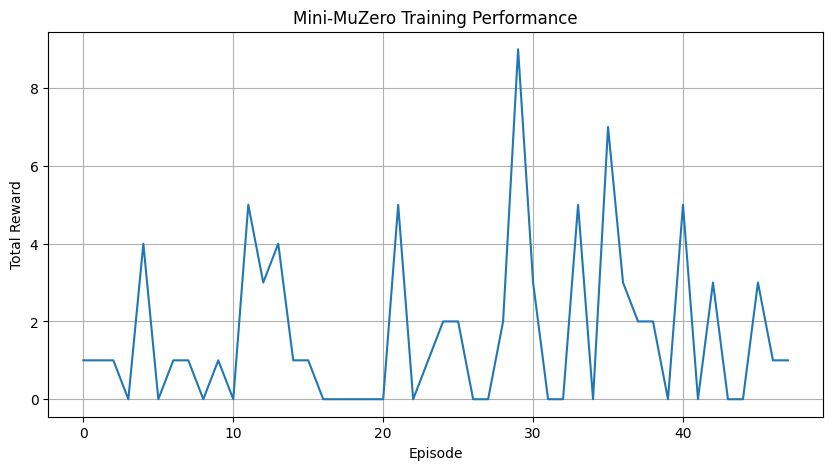

In [52]:
plt.figure(figsize=(10,5))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Mini-MuZero Training Performance")
plt.grid()
plt.show()


moving average curve

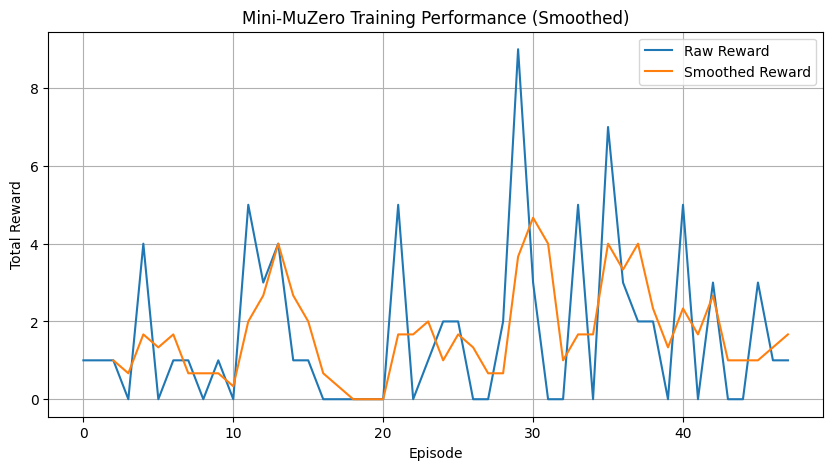

In [53]:
def moving_average(data, window=3):
    return np.convolve(data, np.ones(window)/window, mode='valid')

smoothed = moving_average(episode_rewards, window=3)

plt.figure(figsize=(10,5))
plt.plot(episode_rewards, label="Raw Reward")
plt.plot(range(2, len(episode_rewards)), smoothed, label="Smoothed Reward")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Mini-MuZero Training Performance (Smoothed)")
plt.legend()
plt.grid()
plt.show()


Upgraded Training Configuration

In [54]:
# ===============================
# UPGRADED TRAINING CONFIGURATION
# ===============================

# Training control
NUM_EPISODES = 60
MAX_STEPS = 10000

# Replay buffer
REPLAY_BUFFER_SIZE = 20000
BATCH_SIZE = 64

# Learning parameters
LEARNING_RATE = 1e-4
GAMMA = 0.99

# Exploration parameters
EPSILON_START = 1.0
EPSILON_END = 0.1
EPSILON_DECAY = 8000  # slower decay for better exploration

print("Updated Training Configuration:")
print("Episodes:", NUM_EPISODES)
print("Max Steps:", MAX_STEPS)
print("Replay Buffer Size:", REPLAY_BUFFER_SIZE)
print("Batch Size:", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)
print("Gamma:", GAMMA)
print("Epsilon Start:", EPSILON_START)
print("Epsilon End:", EPSILON_END)
print("Epsilon Decay:", EPSILON_DECAY)


Updated Training Configuration:
Episodes: 60
Max Steps: 10000
Replay Buffer Size: 20000
Batch Size: 64
Learning Rate: 0.0001
Gamma: 0.99
Epsilon Start: 1.0
Epsilon End: 0.1
Epsilon Decay: 8000


Create Unified MuZero Model Wrapper

In [55]:
import torch
import torch.nn as nn

class MiniMuZero(nn.Module):
    def __init__(self, representation, prediction, dynamics):
        super().__init__()
        self.representation = representation
        self.prediction = prediction
        self.dynamics = dynamics

    def forward(self, state):
        latent = self.representation(state)
        policy_logits, value = self.prediction(latent)
        return policy_logits, value

# Use the correct variable names from your notebook
model = MiniMuZero(representation_net, prediction_net, dynamics_net).to(device)

print("Model created successfully.")


Model created successfully.


Optimizer Setup

In [56]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print("Optimizer initialized.")


Optimizer initialized.


Upgraded Training Loop

In [57]:
import random
import torch.nn.functional as F
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

# Reset replay buffer
replay_buffer = deque(maxlen=REPLAY_BUFFER_SIZE)

episode_rewards = []
global_step = 0

def epsilon_by_step(step):
    epsilon = EPSILON_END + (EPSILON_START - EPSILON_END) * \
              np.exp(-1.0 * step / EPSILON_DECAY)
    return max(epsilon, 0.2)  # prevent full collapse


for episode in range(60):

    state, _ = env.reset()
    episode_reward = 0
    done = False

    while not done and global_step < 10000:

        epsilon = epsilon_by_step(global_step)

        state_tensor = torch.tensor(np.array(state)).unsqueeze(0).float().to(device) / 255.0

        # Epsilon-greedy action
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                latent = model.representation(state_tensor)
                policy_logits, _ = model.prediction(latent)
                probs = torch.softmax(policy_logits, dim=1)
                action = torch.argmax(probs, dim=1).item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        replay_buffer.append((state, action, reward, next_state, done))
        state = next_state
        episode_reward += reward
        global_step += 1

        # Training step
        if len(replay_buffer) > BATCH_SIZE:

            batch = random.sample(replay_buffer, BATCH_SIZE)
            states, actions, rewards, next_states, dones = zip(*batch)

            states = torch.tensor(np.array(states)).float().to(device) / 255.0
            next_states = torch.tensor(np.array(next_states)).float().to(device) / 255.0
            actions = torch.tensor(actions).to(device)
            rewards = torch.tensor(rewards).float().to(device)
            dones = torch.tensor(dones).float().to(device)

            # Forward pass
            latent = model.representation(states)
            policy_logits, values = model.prediction(latent)

            with torch.no_grad():
                next_latent = model.representation(next_states)
                _, next_values = model.prediction(next_latent)

            values = values.squeeze()
            next_values = next_values.squeeze()

            targets = rewards + GAMMA * next_values * (1 - dones)

            loss = F.mse_loss(values, targets)

            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping (stability fix)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)

            optimizer.step()

        if global_step >= 10000:
            break

    episode_rewards.append(episode_reward)

    if episode % 5 == 0:
        print(f"Episode {episode} | Reward: {episode_reward} | Epsilon: {epsilon:.3f}")

print("Stable Training Completed.")


Episode 0 | Reward: 1.0 | Epsilon: 0.982
Episode 5 | Reward: 4.0 | Epsilon: 0.864
Episode 10 | Reward: 0.0 | Epsilon: 0.756
Episode 15 | Reward: 2.0 | Epsilon: 0.665
Episode 20 | Reward: 2.0 | Epsilon: 0.609
Episode 25 | Reward: 2.0 | Epsilon: 0.545
Episode 30 | Reward: 4.0 | Epsilon: 0.478
Episode 35 | Reward: 4.0 | Epsilon: 0.418
Episode 40 | Reward: 0.0 | Epsilon: 0.375
Episode 45 | Reward: 0 | Epsilon: 0.358
Episode 50 | Reward: 0 | Epsilon: 0.358
Episode 55 | Reward: 0 | Epsilon: 0.358
Stable Training Completed.


plot curve

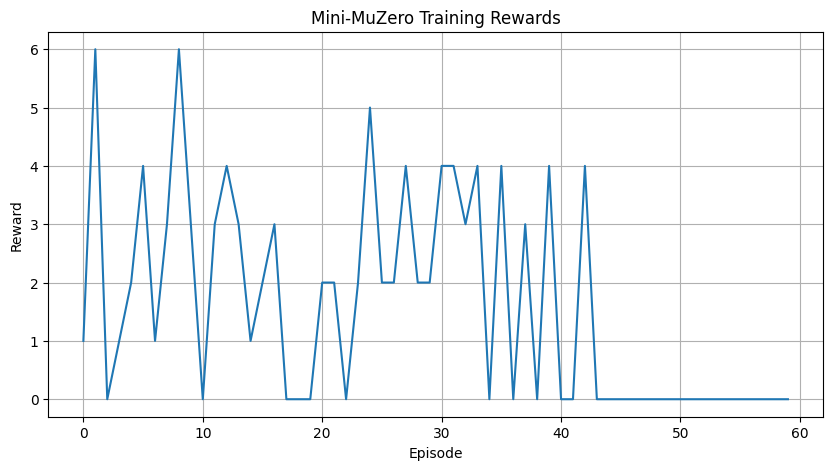

In [58]:
plt.figure(figsize=(10,5))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Mini-MuZero Training Rewards")
plt.grid()
plt.show()


moving avergae curve

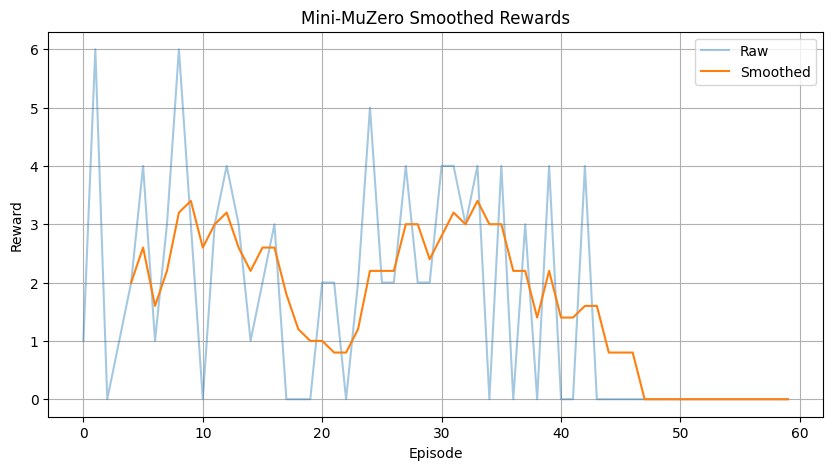

In [59]:
def moving_average(data, window=5):
    return np.convolve(data, np.ones(window)/window, mode='valid')

smoothed = moving_average(episode_rewards, window=5)

plt.figure(figsize=(10,5))
plt.plot(episode_rewards, alpha=0.4, label="Raw")
plt.plot(range(4, len(episode_rewards)), smoothed, label="Smoothed")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Mini-MuZero Smoothed Rewards")
plt.legend()
plt.grid()
plt.show()


In [60]:
# ===============================
# STABLE TRAINING CONFIGURATION
# ===============================

EPISODES = 60
MAX_STEPS = 10000

REPLAY_BUFFER_SIZE = 20000
BATCH_SIZE = 64

LEARNING_RATE = 5e-5   # reduced for stability
GAMMA = 0.99

EPSILON_START = 1.0
EPSILON_END = 0.1
EPSILON_DECAY = 8000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Config loaded.")
print("Device:", device)


Config loaded.
Device: cuda


Define Networks + Full Mini-MuZero Model

In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ===============================
# Representation Network (h)
# ===============================
class RepresentationNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.float() / 255.0
        return self.conv(x)


# ===============================
# Prediction Network (f)
# ===============================
class PredictionNetwork(nn.Module):
    def __init__(self, action_space):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU()
        )

        self.policy_head = nn.Linear(512, action_space)
        self.value_head = nn.Linear(512, 1)

    def forward(self, latent):
        x = self.fc(latent)
        policy = self.policy_head(x)
        value = self.value_head(x)
        return policy, value


# ===============================
# Dynamics Network (g)
# ===============================
class DynamicsNetwork(nn.Module):
    def __init__(self, action_space):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(64 + action_space, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.reward_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 1)
        )

        self.action_space = action_space

    def forward(self, latent, action):
        batch_size = latent.size(0)

        action_onehot = F.one_hot(action, self.action_space)
        action_onehot = action_onehot.view(batch_size, self.action_space, 1, 1)
        action_onehot = action_onehot.expand(-1, -1, 7, 7).float()

        x = torch.cat([latent, action_onehot], dim=1)

        next_latent = self.conv(x)
        reward = self.reward_head(next_latent)

        return next_latent, reward


# ===============================
# Full Mini-MuZero Model
# ===============================
class MiniMuZero(nn.Module):
    def __init__(self, action_space):
        super().__init__()
        self.representation = RepresentationNetwork()
        self.prediction = PredictionNetwork(action_space)
        self.dynamics = DynamicsNetwork(action_space)

    def initial_inference(self, state):
        latent = self.representation(state)
        policy, value = self.prediction(latent)
        return latent, policy, value

    def recurrent_inference(self, latent, action):
        next_latent, reward = self.dynamics(latent, action)
        policy, value = self.prediction(next_latent)
        return next_latent, reward, policy, value


# Create model
ACTION_SPACE = 4  # Breakout actions
model = MiniMuZero(ACTION_SPACE).to(device)

print("Model created successfully.")


Model created successfully.


Optimizer + Replay Buffer + Loss

In [62]:
import torch.optim as optim
from collections import deque
import random

# Replay Buffer
replay_buffer = deque(maxlen=REPLAY_BUFFER_SIZE)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Loss functions
value_loss_fn = nn.MSELoss()
reward_loss_fn = nn.MSELoss()
policy_loss_fn = nn.CrossEntropyLoss()

print("Optimizer and replay buffer initialized.")


Optimizer and replay buffer initialized.


Reduce Learning Rate

In [63]:
for param_group in optimizer.param_groups:
    param_group['lr'] = 5e-5

print("Learning rate updated to:", optimizer.param_groups[0]['lr'])


Learning rate updated to: 5e-05


Collect Final Reward Arrays

In [64]:
print("Mini-MuZero episodes:", len(episode_rewards))


Mini-MuZero episodes: 60


Create Proper Evaluation Environment

In [65]:
import gymnasium as gym
import ale_py
import os
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation, RecordVideo

gym.register_envs(ale_py)

video_folder = "muzero_videos"
os.makedirs(video_folder, exist_ok=True)

# IMPORTANT: frameskip=1 here
eval_env = gym.make(
    "ALE/Breakout-v5",
    render_mode="rgb_array",
    frameskip=1
)

eval_env = AtariPreprocessing(
    eval_env,
    frame_skip=4,
    screen_size=84,
    grayscale_obs=True
)

eval_env = FrameStackObservation(eval_env, stack_size=4)

eval_env = RecordVideo(
    eval_env,
    video_folder=video_folder,
    episode_trigger=lambda x: True
)

print("Evaluation environment ready successfully.")


Evaluation environment ready successfully.


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:434: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/muzero_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Record Mini-MuZero Evaluation Episodes

In [68]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from gymnasium.wrappers.atari_preprocessing import AtariPreprocessing
from gymnasium.wrappers import FrameStackObservation
import os

video_folder = "muzero_videos"
os.makedirs(video_folder, exist_ok=True)

eval_env = gym.make("ALE/Breakout-v5", render_mode="rgb_array", frameskip=1)

eval_env = AtariPreprocessing(
    eval_env,
    frame_skip=4,
    screen_size=84,
    grayscale_obs=True,
)

eval_env = FrameStackObservation(eval_env, 4)

eval_env = RecordVideo(
    eval_env,
    video_folder=video_folder,
    episode_trigger=lambda episode_id: episode_id < 3,
    name_prefix="muzero_eval"
)

print("Evaluation environment ready successfully.")


Evaluation environment ready successfully.


In [69]:
model.eval()

NUM_EVAL_EPISODES = 5
MAX_EVAL_STEPS = 2000   # safety limit so it doesn't run forever

for ep in range(NUM_EVAL_EPISODES):

    state, _ = eval_env.reset()
    done = False
    total_reward = 0
    step_count = 0

    while not done and step_count < MAX_EVAL_STEPS:
        state_tensor = torch.tensor(np.array(state)).unsqueeze(0).float().to(device) / 255.0

        with torch.no_grad():
            latent = model.representation(state_tensor)
            policy_logits, _ = model.prediction(latent)
            action = torch.argmax(policy_logits, dim=1).item()

        state, reward, terminated, truncated, _ = eval_env.step(action)
        done = terminated or truncated
        total_reward += reward
        step_count += 1

    print(f"Evaluation Episode {ep} | Reward: {total_reward}")

eval_env.close()

print("Mini-MuZero evaluation recording complete.")


Evaluation Episode 0 | Reward: 0.0
Evaluation Episode 1 | Reward: 0.0
Evaluation Episode 2 | Reward: 0.0
Evaluation Episode 3 | Reward: 0.0
Evaluation Episode 4 | Reward: 0.0
Mini-MuZero evaluation recording complete.


In [71]:
model.eval()

state, _ = env.reset()

state_tensor = torch.tensor(np.array(state)).unsqueeze(0).float().to(device) / 255.0

with torch.no_grad():
    latent = model.representation(state_tensor)
    policy_logits, _ = model.prediction(latent)
    probs = torch.softmax(policy_logits, dim=1)

print("Action probabilities:", probs)
print("Chosen action:", torch.argmax(probs, dim=1).item())


Action probabilities: tensor([[0.2480, 0.2450, 0.2598, 0.2472]], device='cuda:0')
Chosen action: 2


In [70]:
from IPython.display import HTML
from base64 import b64encode

video_path = "muzero_videos/rl-video-episode-0.mp4"

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=600 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")


Add Target Network

In [72]:
import copy

target_model = copy.deepcopy(model)
target_model.load_state_dict(model.state_dict())
target_model.eval()

print("Target network created.")


Target network created.


Real Q-Learning Upgrade

In [74]:
import random
import torch.nn.functional as F
from collections import deque
import numpy as np

# Hyperparameters
EPISODES = 350
MAX_STEPS = 100000
BATCH_SIZE = 64
GAMMA = 0.99
TARGET_UPDATE = 1000

replay_buffer = deque(maxlen=30000)

episode_rewards = []
global_step = 0








for episode in range(EPISODES):

    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done and global_step < MAX_STEPS:


        epsilon = max(0.1, 1.0 - global_step / 80000)

        state_tensor = torch.tensor(np.array(state)).unsqueeze(0).float().to(device) / 255.0

        # Epsilon-greedy
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                latent = model.representation(state_tensor)
                q_values, _ = model.prediction(latent)
                action = torch.argmax(q_values, dim=1).item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        replay_buffer.append((state, action, reward, next_state, done))
        state = next_state
        total_reward += reward
        global_step += 1

        # Train
        if len(replay_buffer) > BATCH_SIZE:

            batch = random.sample(replay_buffer, BATCH_SIZE)
            states, actions, rewards, next_states, dones = zip(*batch)

            states = torch.tensor(np.array(states)).float().to(device) / 255.0
            next_states = torch.tensor(np.array(next_states)).float().to(device) / 255.0
            actions = torch.tensor(actions).to(device)
            rewards = torch.tensor(rewards).float().to(device)
            dones = torch.tensor(dones).float().to(device)

            # Current Q
            latent = model.representation(states)
            q_values, _ = model.prediction(latent)
            current_q = q_values.gather(1, actions.unsqueeze(1)).squeeze()

            # Target Q
            with torch.no_grad():
                next_latent = target_model.representation(next_states)
                next_q_values, _ = target_model.prediction(next_latent)
                max_next_q = next_q_values.max(1)[0]
                target_q = rewards + GAMMA * max_next_q * (1 - dones)

            loss = F.mse_loss(current_q, target_q)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            optimizer.step()

        # Update target network
        if global_step % TARGET_UPDATE == 0:
            target_model.load_state_dict(model.state_dict())

        if global_step >= MAX_STEPS:
            break

    episode_rewards.append(total_reward)

    if episode % 10 == 0:
        print(f"Episode {episode} | Reward: {total_reward} | Epsilon: {epsilon:.3f}")

print("Upgraded Training Completed.")


Episode 0 | Reward: 0.0 | Epsilon: 0.998
Episode 10 | Reward: 1.0 | Epsilon: 0.975
Episode 20 | Reward: 1.0 | Epsilon: 0.952
Episode 30 | Reward: 5.0 | Epsilon: 0.924
Episode 40 | Reward: 0.0 | Epsilon: 0.904
Episode 50 | Reward: 2.0 | Epsilon: 0.879
Episode 60 | Reward: 3.0 | Epsilon: 0.856
Episode 70 | Reward: 0.0 | Epsilon: 0.835
Episode 80 | Reward: 0.0 | Epsilon: 0.812
Episode 90 | Reward: 0.0 | Epsilon: 0.789
Episode 100 | Reward: 0.0 | Epsilon: 0.763
Episode 110 | Reward: 1.0 | Epsilon: 0.739
Episode 120 | Reward: 0.0 | Epsilon: 0.718
Episode 130 | Reward: 1.0 | Epsilon: 0.696
Episode 140 | Reward: 0.0 | Epsilon: 0.676
Episode 150 | Reward: 0.0 | Epsilon: 0.655
Episode 160 | Reward: 2.0 | Epsilon: 0.631
Episode 170 | Reward: 1.0 | Epsilon: 0.609
Episode 180 | Reward: 2.0 | Epsilon: 0.585
Episode 190 | Reward: 1.0 | Epsilon: 0.560
Episode 200 | Reward: 1.0 | Epsilon: 0.533
Episode 210 | Reward: 1.0 | Epsilon: 0.505
Episode 220 | Reward: 2.0 | Epsilon: 0.481
Episode 230 | Reward: 

In [75]:
print("Global step:", global_step)


Global step: 68943


Save Everything

In [76]:
import torch

# Save main model
torch.save(model.state_dict(), "muzero_model.pth")

# Save target model
torch.save(target_model.state_dict(), "muzero_target_model.pth")

# Save optimizer state
torch.save(optimizer.state_dict(), "muzero_optimizer.pth")

# Save replay buffer
import pickle
with open("muzero_replay.pkl", "wb") as f:
    pickle.dump(replay_buffer, f)

# Save training metadata
training_state = {
    "global_step": global_step,
    "episode_rewards": episode_rewards
}

with open("muzero_training_state.pkl", "wb") as f:
    pickle.dump(training_state, f)

print("Everything saved successfully.")


Everything saved successfully.


In [77]:
from google.colab import files
files.download("muzero_model.pth")
files.download("muzero_target_model.pth")
files.download("muzero_optimizer.pth")
files.download("muzero_replay.pkl")
files.download("muzero_training_state.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

resume code by running this

In [78]:
model.load_state_dict(torch.load("muzero_model.pth"))
target_model.load_state_dict(torch.load("muzero_target_model.pth"))
optimizer.load_state_dict(torch.load("muzero_optimizer.pth"))

import pickle
with open("muzero_replay.pkl", "rb") as f:
    replay_buffer = pickle.load(f)

with open("muzero_training_state.pkl", "rb") as f:
    training_state = pickle.load(f)

global_step = training_state["global_step"]
episode_rewards = training_state["episode_rewards"]

print("Training resumed from step:", global_step)


Training resumed from step: 68943
